In [12]:
# Cell 1 (Classification): Imports and Constants for Multi-Modal Classification

import os
import glob
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Reshape, LeakyReLU, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy # For binary classification (e.g., risk vs no-risk)
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall # Useful for imbalanced datasets
from tensorflow.keras.utils import to_categorical # Only if NUM_HEATMAP_CLASSES > 2
import logging
import random
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logging.info("Initialized script for Multi-Modal Classification model.")

# Define image dimensions (should match output from preprocessing)
IMG_HEIGHT = 512 
IMG_WIDTH = 640 

# Define channels for each modality
RGB_CHANNELS = 3
THERMAL_CHANNELS = 1 # Thermal images are grayscale (single channel)

# Define parameters for grid-level classification / heatmap generation
# This defines the size of the patches that the model will classify
GRID_SIZE = 32 # E.g., divide the 512x640 image into 32x32 pixel patches

# Number of output classes for each grid cell (e.g., 1 for probability score, 2 for binary risk)
# For a 'predictive heatmap', outputting a single probability (0-1) is common,
# which can then be visualized with a color scale.
NUM_HEATMAP_CLASSES = 1 # For regression-like output (probability 0-1) per grid cell
# Alternatively, if you want discrete risk categories per grid cell (e.g., No-Risk, Low, Medium, High):
# NUM_HEATMAP_CLASSES = 4 

# Training parameters
BATCH_SIZE = 16 # Might need adjustment based on GPU memory
EPOCHS = 100 # Placeholder, adjust based on convergence

# Path to your preprocessed data from previous steps
OUTPUT_BASE_DIR = 'outputs\processed_flame3_dataset'

logging.info(f"Image dimensions set to: {IMG_HEIGHT}x{IMG_WIDTH}")
logging.info(f"Grid cell size for classification: {GRID_SIZE}x{GRID_SIZE}")
logging.info(f"Number of heatmap output classes: {NUM_HEATMAP_CLASSES}")
logging.info(f"Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")
logging.info(f"Loading preprocessed data from: {OUTPUT_BASE_DIR}")

print("Classification setup complete. Ready to load and prepare multi-modal data.")


2025-07-28 05:00:17,338 - INFO - Initialized script for Multi-Modal Classification model.
2025-07-28 05:00:17,340 - INFO - Image dimensions set to: 512x640
2025-07-28 05:00:17,343 - INFO - Grid cell size for classification: 32x32
2025-07-28 05:00:17,345 - INFO - Number of heatmap output classes: 1
2025-07-28 05:00:17,346 - INFO - Batch size: 16, Epochs: 100
2025-07-28 05:00:17,348 - INFO - Loading preprocessed data from: outputs\processed_flame3_dataset


Classification setup complete. Ready to load and prepare multi-modal data.


In [8]:
# Cell 2 (Classification): Data Loading and Preprocessing for Multi-Modal Classification (REVISED - Thermal Image Channel Dimension)
def load_image_patch(image_path, img_height, img_width, target_channels):
    """
    Loads an image, resizes it, and normalizes pixel values.
    Handles RGB and grayscale thermal images. Ensures float32 and correct dimensions.
    """
    logging.debug(f"Attempting to load image: {image_path} with {target_channels} channels.")
    image = None
    if target_channels == 3: # RGB
        image = cv2.imread(image_path)
        if image is None:
            logging.error(f"Failed to load RGB image (imread returned None): {image_path}")
            return None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB
    elif target_channels == 1: # Thermal (grayscale)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            logging.error(f"Failed to load Thermal image (imread returned None): {image_path}")
            return None
        # Initial expand_dims might be applied here, but will be re-checked after resize
        image = np.expand_dims(image, axis=-1) if image.ndim == 2 else image # Ensure it's 3D if loaded as 2D
    else:
        logging.error(f"Unsupported number of channels: {target_channels} for image: {image_path}")
        return None

    try:
        image = cv2.resize(image, (img_width, img_height))
        # Ensure thermal images (1 channel) always have the channel dimension after resize
        if target_channels == 1 and image.ndim == 2:
            image = np.expand_dims(image, axis=-1)
        image = image.astype(np.float32) / 255.0 # Normalize to 0-1 range for 8-bit images
        logging.debug(f"Successfully loaded and processed image: {image_path}")
        return image
    except Exception as e:
        logging.error(f"Error during image resize/normalization/dimension check for {image_path}: {e}")
        return None

def generate_synthetic_heatmap(img_height, img_width, thermal_image_path=None, num_fallback_hotspots=3, 
                               min_radius=20, max_radius=80, affinity_offset=50, spike_intensity_threshold=180): # Red+Green Threshold
    """
    Generates a synthetic grayscale heatmap with "hotspots" based on the affinity of actual thermal hotspots.
    Heat detection now uses the red AND green channels of the _regenerated_thermal.jpg image to identify spikes.
    This function is now ONLY called for 'Fire' folder images.
    Values are 0-1 (normalized). Ensures float32.
    
    Args:
        img_height, img_width (int): Dimensions of the heatmap.
        thermal_image_path (str, optional): Path to the corresponding _regenerated_thermal.jpg image.
        num_fallback_hotspots (int): Number of random hotspots if thermal detection fails.
        min_radius, max_radius (int): Min/max radius for synthetic hotspots.
        affinity_offset (int): Max pixel offset from detected thermal hotspot centroid.
        spike_intensity_threshold (int): Pixel intensity threshold for detecting "hot" areas
                                        in the combined red and green channels (0-255).
    """
    synthetic_heatmap = np.zeros((img_height, img_width), dtype=np.float32) # Ensure dtype is float32
    hotspot_locations = []

    if thermal_image_path and os.path.exists(thermal_image_path):
        # Load as color image to analyze red and green channels
        thermal_img_raw_color = cv2.imread(thermal_image_path)
        if thermal_img_raw_color is not None:
            thermal_img_rgb = cv2.cvtColor(thermal_img_raw_color, cv2.COLOR_BGR2RGB)
            red_channel = thermal_img_rgb[:, :, 0] # Extract the red channel
            green_channel = thermal_img_rgb[:, :, 1] # Extract the green channel
            
            # Combine red and green channels to identify "spikes"
            # Using a simple average for now; could be more complex later if needed
            spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)
            
            spike_intensity_map_resized = cv2.resize(spike_intensity_map, (img_width, img_height))
            
            # Apply Gaussian Blur before thresholding for better contour detection
            blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)
            
            # Threshold the combined intensity map to identify hot regions
            _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
            
            # Find contours of the hot regions
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                # Reduced minimum contour area to account for small spikes from drone images
                if cv2.contourArea(contour) > 10: 
                    M = cv2.moments(contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                        hotspot_locations.append((cx, cy))
            
            if hotspot_locations:
                logging.info(f"Generated synthetic heatmap based on {len(hotspot_locations)} detected thermal hotspots from {os.path.basename(thermal_image_path)} using red+green spike detection.")
            else:
                logging.warning(f"No significant thermal hotspots detected in {os.path.basename(thermal_image_path)} above spike intensity threshold {spike_intensity_threshold}. Falling back to random hotspots.")
                # Fallback to random hotspots if no thermal hotspots were found
                for _ in range(num_fallback_hotspots):
                    hotspot_locations.append((np.random.randint(0, img_width), np.random.randint(0, img_height)))
                logging.info(f"Generated {num_fallback_hotspots} random synthetic hotspots as a fallback.")
        else:
            logging.warning(f"Could not load thermal image for intelligent synthetic heatmap: {thermal_image_path}. Generating blank heatmap as fallback.")
    else: # If thermal path is invalid/missing (should not happen if called correctly for Fire images)
        logging.warning(f"Thermal image path invalid or not found: {thermal_image_path}. Generating blank heatmap as fallback.")

    # Place synthetic hotspots around identified thermal locations (only if hotspot_locations is populated)
    for center_x, center_y in hotspot_locations:
        # Add a random offset for "affinity"
        offset_x = np.random.randint(-affinity_offset, affinity_offset + 1)
        offset_y = np.random.randint(-affinity_offset, affinity_offset + 1)
        
        draw_x = np.clip(center_x + offset_x, 0, img_width - 1)
        draw_y = np.clip(center_y + offset_y, 0, img_height - 1)

        radius = np.random.randint(min_radius, max_radius)
        
        cv2.circle(synthetic_heatmap, (draw_x, draw_y), radius, (1.0), -1) 
    
    synthetic_heatmap = cv2.GaussianBlur(synthetic_heatmap, (5, 5), 0)
    synthetic_heatmap = np.clip(synthetic_heatmap, 0.0, 1.0)
    
    return synthetic_heatmap

def load_multi_modal_grid_data(rgb_image_path, thermal_image_path, ground_truth_heatmap_path,
                               img_height, img_width, grid_size, num_heatmap_classes):
    """
    Loads full RGB and Thermal images, a ground truth heatmap (or generates a synthetic one),
    and extracts grid-sized patches with corresponding labels.
    
    Crucially, for 'No_Fire' images, heatmap generation is explicitly skipped,
    and a blank heatmap is used.
    """
    logging.debug(f"Processing image pair: RGB={rgb_image_path}, Thermal={thermal_image_path}")

    # Load full RGB and Thermal images
    full_rgb = load_image_patch(rgb_image_path, img_height, img_width, RGB_CHANNELS)
    full_thermal = load_image_patch(thermal_image_path, img_height, img_width, THERMAL_CHANNELS)

    if full_rgb is None or full_thermal is None:
        logging.error(f"Skipping pair due to failed image loading: RGB={rgb_image_path}, Thermal={thermal_image_path}")
        return None, None, None

    # --- Load or Generate Ground Truth Heatmap (Conditional on Folder Type) ---
    ground_truth_heatmap = None
    is_fire_image = 'Fire' in os.path.dirname(thermal_image_path) # Check folder type

    if is_fire_image:
        if os.path.exists(ground_truth_heatmap_path):
            # Load real ground truth heatmap
            ground_truth_heatmap = cv2.imread(ground_truth_heatmap_path, cv2.IMREAD_GRAYSCALE)
            if ground_truth_heatmap is None:
                logging.error(f"Failed to load real ground truth heatmap (imread returned None): {ground_truth_heatmap_path}. Generating intelligent synthetic as fallback.")
                ground_truth_heatmap = generate_synthetic_heatmap(img_height, img_width, thermal_image_path) # Pass thermal path
            else:
                logging.info(f"Successfully loaded real ground truth heatmap: {ground_truth_heatmap_path}")
                # Resize and normalize real heatmap
                ground_truth_heatmap = cv2.resize(ground_truth_heatmap, (img_width, img_height), interpolation=cv2.INTER_LINEAR if num_heatmap_classes == 1 else cv2.INTER_NEAREST)
                ground_truth_heatmap = ground_truth_heatmap.astype(np.float32) / 255.0 # Ensure float32
        else:
            # Generate intelligent synthetic ground truth heatmap if file doesn't exist
            logging.warning(f"Ground truth heatmap not found at: {ground_truth_heatmap_path}. Generating intelligent synthetic heatmap for this Fire image based on thermal data.")
            ground_truth_heatmap = generate_synthetic_heatmap(img_height, img_width, thermal_image_path) # Pass thermal path
    else: # This is a 'No_Fire' image
        logging.info(f"Image {os.path.basename(thermal_image_path)} is from No_Fire folder. Heatmap generation/loading is skipped; a blank heatmap is used.")
        ground_truth_heatmap = np.zeros((img_height, img_width), dtype=np.float32) # Directly assign blank heatmap

    if ground_truth_heatmap is None: # Should not happen with direct assignment or synthetic fallback, but good check
        logging.error(f"No ground truth heatmap (real or synthetic) available for {rgb_image_path}. Skipping.")
        return None, None, None

    all_rgb_patches = []
    all_thermal_patches = []
    all_labels = []

    for y in range(0, img_height, grid_size):
        for x in range(0, img_width, grid_size):
            y_end = min(y + grid_size, img_height)
            x_end = min(x + grid_size, img_width)

            if (y_end - y) != grid_size or (x_end - x) != grid_size:
                logging.debug(f"Skipping incomplete patch at ({y},{x}) for image {os.path.basename(rgb_image_path)}")
                continue

            rgb_patch = full_rgb[y:y_end, x:x_end]
            thermal_patch = full_thermal[y:y_end, x:x_end]
            
            patch_heatmap_region = ground_truth_heatmap[y:y_end, x:x_end]
            
            if num_heatmap_classes == 1: # Probability (0-1)
                label = np.mean(patch_heatmap_region).astype(np.float32) # Ensure label is float32
                label = np.clip(label, 0.0, 1.0)
            else: # Categorical
                values, counts = np.unique(patch_heatmap_region.round(), return_counts=True)
                # Handle empty patch_heatmap_region if it somehow occurs
                if len(values) == 0:
                    logging.warning(f"Empty patch_heatmap_region at ({y},{x}) for {os.path.basename(rgb_image_path)}. Assigning default label 0.")
                    label = tf.keras.utils.to_categorical(0, num_classes=num_heatmap_classes).astype(np.float32) # Ensure float32
                else:
                    label = values[np.argmax(counts)]
                    label = tf.keras.utils.to_categorical(int(label), num_classes=num_heatmap_classes).astype(np.float32) # Ensure float32
            
            all_rgb_patches.append(rgb_patch)
            all_thermal_patches.append(thermal_patch)
            all_labels.append(label)

    logging.debug(f"Extracted {len(all_rgb_patches)} patches from {os.path.basename(rgb_image_path)}")
    return all_rgb_patches, all_thermal_patches, all_labels

def multi_modal_data_generator(rgb_patch_list, thermal_patch_list, label_list, batch_size):
    """
    A generator that yields batches of multi-modal image patches and labels for training.
    Yields a tuple (inputs, targets) where inputs is a tuple (rgb_batch, thermal_batch).
    """
    num_samples = len(rgb_patch_list)
    indices = np.arange(num_samples)

    while True:
        np.random.shuffle(indices)
        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i+batch_size]
            
            batch_rgb_patches = []
            batch_thermal_patches = []
            batch_labels = []
            
            for idx in batch_indices:
                batch_rgb_patches.append(rgb_patch_list[idx])
                batch_thermal_patches.append(thermal_patch_list[idx])
                batch_labels.append(label_list[idx])
            
            # Ensure the output arrays are float32
            labels_array = np.array(batch_labels, dtype=np.float32)
            if NUM_HEATMAP_CLASSES == 1 and labels_array.ndim == 1:
                labels_array = np.expand_dims(labels_array, axis=-1)

            # Yield a tuple of (inputs, targets) where inputs is also a tuple
            yield (np.array(batch_rgb_patches, dtype=np.float32), np.array(batch_thermal_patches, dtype=np.float32)), labels_array

# --- Example Usage (main data loading and splitting logic) ---

logging.info(f"Searching for preprocessed data in: {os.path.abspath(OUTPUT_BASE_DIR)}")

fire_rgb_files = sorted(glob.glob(os.path.join(OUTPUT_BASE_DIR, 'Fire', '*_aligned_rgb.jpg')))
logging.info(f"Found {len(fire_rgb_files)} RGB files in '{os.path.join(OUTPUT_BASE_DIR, 'Fire')}' matching '*_aligned_rgb.jpg'.")

# Now looking for _regenerated_thermal.jpg files
fire_thermal_files = sorted(glob.glob(os.path.join(OUTPUT_BASE_DIR, 'Fire', '*_regenerated_thermal.jpg')))
logging.info(f"Found {len(fire_thermal_files)} Thermal files in '{os.path.join(OUTPUT_BASE_DIR, 'Fire')}' matching '*_regenerated_thermal.jpg'.")

no_fire_rgb_files = sorted(glob.glob(os.path.join(OUTPUT_BASE_DIR, 'No_Fire', '*_aligned_rgb.jpg')))
logging.info(f"Found {len(no_fire_rgb_files)} RGB files in '{os.path.join(OUTPUT_BASE_DIR, 'No_Fire')}' matching '*_aligned_rgb.jpg'.")

# Now looking for _regenerated_thermal.jpg files
no_fire_thermal_files = sorted(glob.glob(os.path.join(OUTPUT_BASE_DIR, 'No_Fire', '*_regenerated_thermal.jpg')))
logging.info(f"Found {len(no_fire_thermal_files)} Thermal files in '{os.path.join(OUTPUT_BASE_DIR, 'No_Fire')}' matching '*_regenerated_thermal.jpg'.")


all_rgb_image_paths = fire_rgb_files + no_fire_rgb_files
all_thermal_image_paths = fire_thermal_files + no_fire_thermal_files

# --- CRITICAL: Match RGB and Thermal files based on their base names ---
paired_files = []
# Lookup key for thermal files now based on '_regenerated_thermal.jpg'
thermal_lookup = {os.path.basename(p).replace('_regenerated_thermal.jpg', ''): p for p in all_thermal_image_paths}

for rgb_path in all_rgb_image_paths:
    base_name = os.path.basename(rgb_path).replace('_aligned_rgb.jpg', '')
    if base_name in thermal_lookup:
        paired_files.append({
            'rgb': rgb_path,
            'thermal': thermal_lookup[base_name],
            'heatmap_dummy_path': os.path.join('synthetic_heatmaps', os.path.basename(os.path.dirname(rgb_path)), f"{base_name}_heatmap.png")
        })
    else:
        logging.warning(f"No matching thermal image (expected format *_regenerated_thermal.jpg) found for RGB file: {rgb_path}. Skipping this pair.")

logging.info(f"Identified {len(paired_files)} correctly matched RGB/Thermal image pairs for processing.")


# Aggregate all patches and labels
all_rgb_patches_list = []
all_thermal_patches_list = []
all_labels_list = []
skipped_files_count = 0

logging.info("Aggregating multi-modal data patches and labels. This may take some time...")

for file_pair in paired_files:
    rgb_path = file_pair['rgb']
    thermal_path = file_pair['thermal']
    heatmap_path = file_pair['heatmap_dummy_path']

    logging.info(f"Attempting to process pair: RGB={os.path.basename(rgb_path)}, Thermal={os.path.basename(thermal_path)}")

    rgb_patches, thermal_patches, labels = load_multi_modal_grid_data(
        rgb_path, thermal_path, heatmap_path, IMG_HEIGHT, IMG_WIDTH, GRID_SIZE, NUM_HEATMAP_CLASSES
    )
    
    if rgb_patches is not None and thermal_patches is not None and labels is not None:
        all_rgb_patches_list.extend(rgb_patches)
        all_thermal_patches_list.extend(thermal_patches)
        all_labels_list.extend(labels)
        logging.info(f"Successfully extracted {len(rgb_patches)} patches from {os.path.basename(rgb_path)}.")
    else:
        skipped_files_count += 1
        logging.error(f"Failed to process pair {os.path.basename(rgb_path)} (see preceding logs for errors). This pair was skipped.")


logging.info(f"Finished aggregating {len(all_rgb_patches_list)} multi-modal patches.")
logging.info(f"Skipped {skipped_files_count} file pairs during detailed processing due to loading issues or no match.")

# Split data into training and validation sets - MEMORY FIX APPLIED HERE
if len(all_rgb_patches_list) > 0:
    num_total_patches = len(all_rgb_patches_list)
    indices = list(range(num_total_patches)) # Create a list of indices
    random.shuffle(indices) # Shuffle the indices

    split_idx = int(num_total_patches * 0.8) # 80% for training

    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]

    # Create new lists by picking elements based on shuffled indices
    # This avoids creating one giant numpy array for all patches.
    train_rgb_patches = [all_rgb_patches_list[i] for i in train_indices]
    train_thermal_patches = [all_thermal_patches_list[i] for i in train_indices]
    train_labels = [all_labels_list[i] for i in train_indices]

    val_rgb_patches = [all_rgb_patches_list[i] for i in val_indices]
    val_thermal_patches = [all_thermal_patches_list[i] for i in val_indices]
    val_labels = [all_labels_list[i] for i in val_indices]

    logging.info(f"Train patches: {len(train_rgb_patches)}, Validation patches: {len(val_labels)}")

    train_generator = multi_modal_data_generator(train_rgb_patches, train_thermal_patches, train_labels, BATCH_SIZE)
    val_generator = multi_modal_data_generator(val_rgb_patches, val_thermal_patches, val_labels, BATCH_SIZE)
else:
    print("No patches generated. Please ensure your preprocessed images exist and are correctly named.")
    train_generator = None
    val_generator = None


print("Multi-modal data loading and preprocessing functions defined, including intelligent synthetic heatmap generation based on red and green channel spikes.")
print("You can now proceed with Cell 3 (Model Definition) and Cell 4 (Training).")
print("Remember: Training on these intelligent synthetic heatmaps will give a better direction, but true proactive prediction requires real pre-ignition ground truth.")

2025-07-28 04:54:43,607 - INFO - Searching for preprocessed data in: d:\Document\GitHub\OMSA\Final_Project\outputs\processed_flame3_dataset
2025-07-28 04:54:43,635 - INFO - Found 622 RGB files in 'outputs\processed_flame3_dataset\Fire' matching '*_aligned_rgb.jpg'.
2025-07-28 04:54:43,649 - INFO - Found 622 Thermal files in 'outputs\processed_flame3_dataset\Fire' matching '*_regenerated_thermal.jpg'.


2025-07-28 04:54:43,664 - INFO - Found 622 RGB files in 'outputs\processed_flame3_dataset\No_Fire' matching '*_aligned_rgb.jpg'.
2025-07-28 04:54:43,680 - INFO - Found 622 Thermal files in 'outputs\processed_flame3_dataset\No_Fire' matching '*_regenerated_thermal.jpg'.
2025-07-28 04:54:43,754 - INFO - Identified 1244 correctly matched RGB/Thermal image pairs for processing.
2025-07-28 04:54:43,784 - INFO - Aggregating multi-modal data patches and labels. This may take some time...
2025-07-28 04:54:43,785 - INFO - Attempting to process pair: RGB=00001_aligned_rgb.jpg, Thermal=00001_regenerated_thermal.jpg
2025-07-28 04:54:43,924 - WARNING - Ground truth heatmap not found at: synthetic_heatmaps\Fire\00001_heatmap.png. Generating intelligent synthetic heatmap for this Fire image based on thermal data.
2025-07-28 04:54:43,944 - INFO - Generated synthetic heatmap based on 25 detected thermal hotspots from 00001_regenerated_thermal.jpg using red+green spike detection.
2025-07-28 04:54:43,974

Multi-modal data loading and preprocessing functions defined, including intelligent synthetic heatmap generation based on red and green channel spikes.
You can now proceed with Cell 3 (Model Definition) and Cell 4 (Training).
Remember: Training on these intelligent synthetic heatmaps will give a better direction, but true proactive prediction requires real pre-ignition ground truth.


2025-07-28 05:00:25,852 - INFO - Generated synthetic heatmap based on 12 detected thermal hotspots from 00207_regenerated_thermal.jpg using red+green spike detection.


Generating visualizations for 2 sample image pairs...


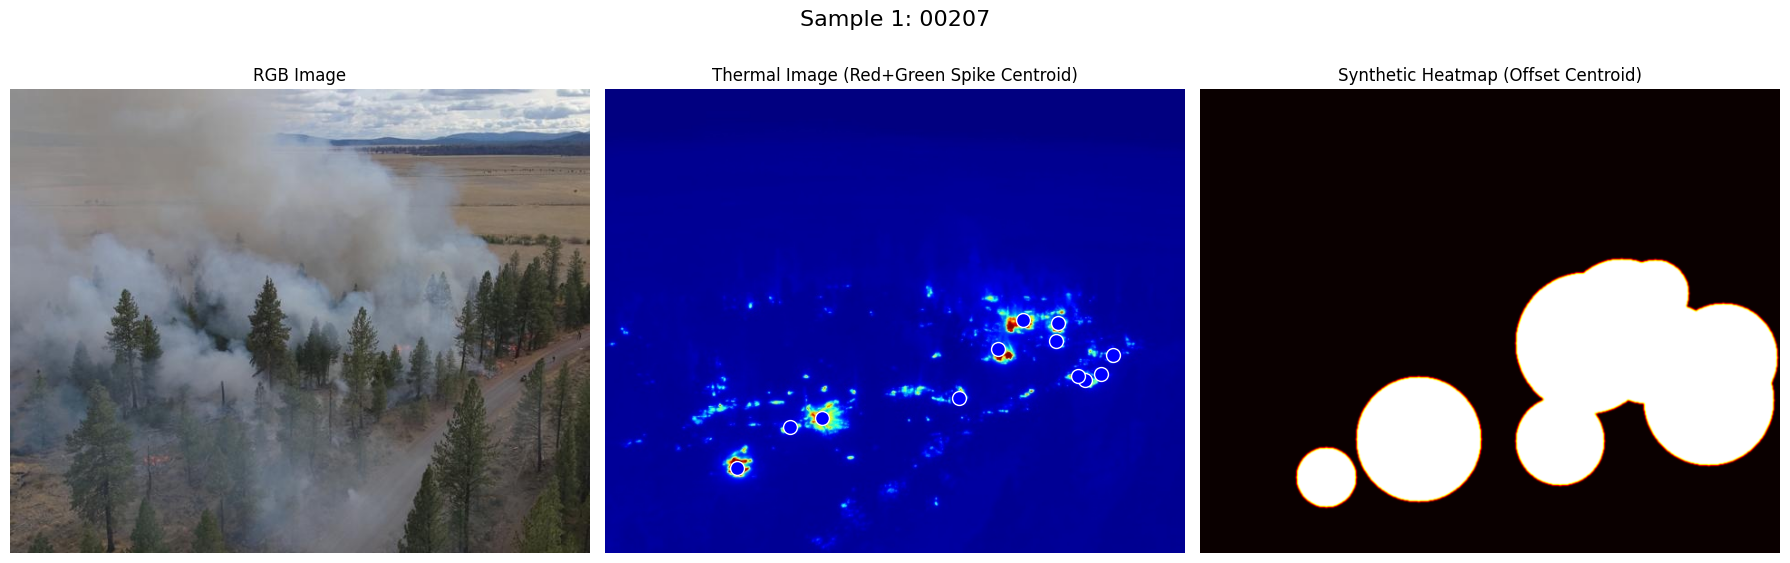

2025-07-28 05:00:28,632 - INFO - Generated synthetic heatmap based on 4 detected thermal hotspots from 00166_regenerated_thermal.jpg using red+green spike detection.


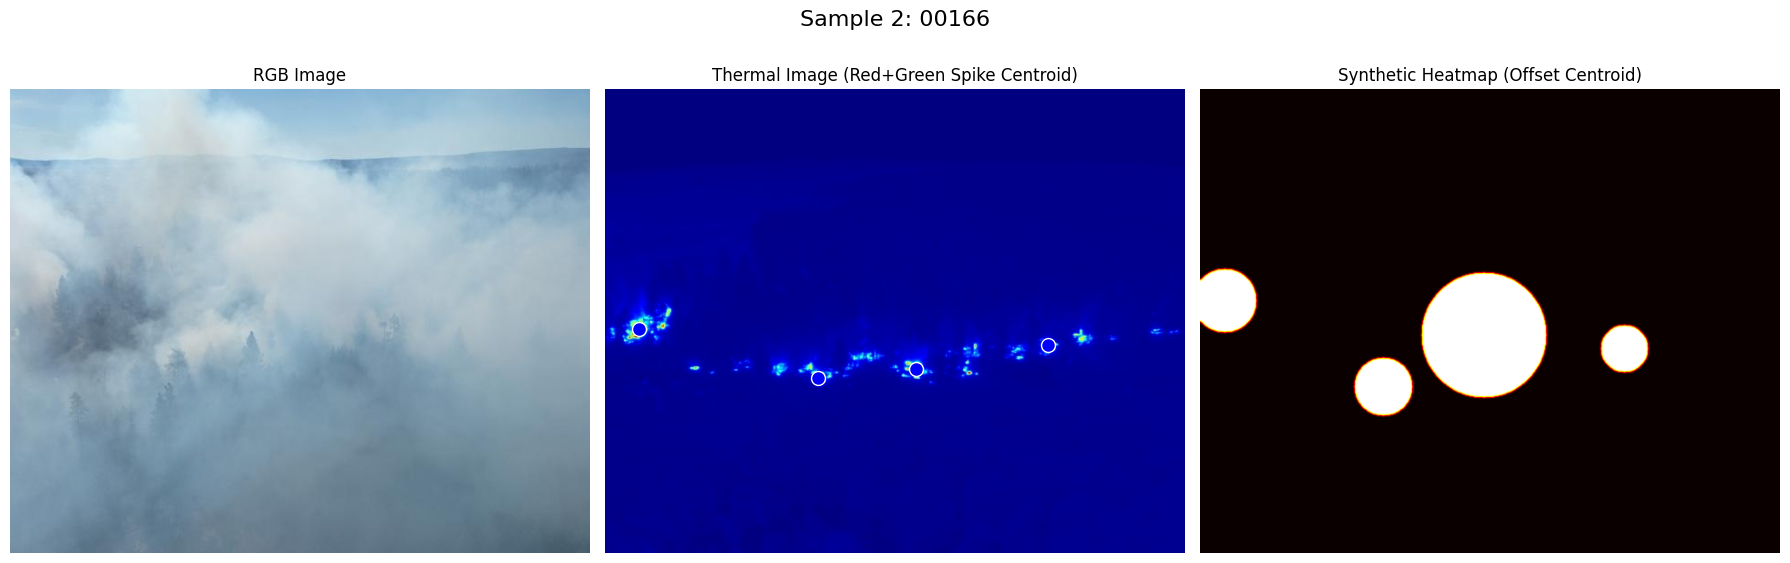


Visualization complete. Please review the generated plots.

--- Clarification on Thermal File Usage ---


In [13]:
# Cell 3 (Classification): Visualization of Thermal, Heatmap, and Centroids for 2 Samples (REVISED - Spike in Red/Green for Heatmap & Centroids)
# Re-define constants from Cell 1 if running this cell in isolation,
# and ensure paired_files, IMG_HEIGHT, IMG_WIDTH, RGB_CHANNELS, THERMAL_CHANNELS, GRID_SIZE, OUTPUT_BASE_DIR are defined
# from Cell 2 execution before running this cell.

# This function is duplicated here for visualization specific centroid capture.
# It is very similar to generate_synthetic_heatmap but returns the drawn centers.
def generate_synthetic_heatmap_and_centers(img_height, img_width, thermal_image_path=None, num_fallback_hotspots=3, 
                                           min_radius=20, max_radius=80, affinity_offset=50, spike_intensity_threshold=180): # Red+Green Threshold
    """
    Generates a synthetic grayscale heatmap with "hotspots" and returns the drawn center points.
    Heat detection now uses the red AND green channels of the _regenerated_thermal.jpg image to identify spikes.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images result in a blank heatmap.
    Values are 0-1 (normalized). Ensures float32.
    
    Returns:
        tuple: (synthetic_heatmap, list_of_drawn_centers)
    """
    synthetic_heatmap = np.zeros((img_height, img_width), dtype=np.float32) # Ensure dtype is float32
    hotspot_locations = []
    synthetic_hotspot_drawn_centers = []

    is_fire_image = 'Fire' in os.path.dirname(thermal_image_path) if thermal_image_path else False

    if is_fire_image and thermal_image_path and os.path.exists(thermal_image_path):
        # Load as color image to analyze red and green channels
        thermal_img_raw_color = cv2.imread(thermal_image_path)
        if thermal_img_raw_color is not None:
            thermal_img_rgb = cv2.cvtColor(thermal_img_raw_color, cv2.COLOR_BGR2RGB)
            red_channel = thermal_img_rgb[:, :, 0] # Extract the red channel
            green_channel = thermal_img_rgb[:, :, 1] # Extract the green channel
            
            # Combine red and green channels to identify "spikes"
            spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)
            
            spike_intensity_map_resized = cv2.resize(spike_intensity_map, (img_width, img_height))
            
            # Apply Gaussian Blur before thresholding for better contour detection
            blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)
            
            # Threshold the combined intensity map to identify hot regions
            _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
            
            # Find contours of the hot regions
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                # Reduced minimum contour area to account for small spikes from drone images
                if cv2.contourArea(contour) > 10: 
                    M = cv2.moments(contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                        hotspot_locations.append((cx, cy))
            
            if hotspot_locations:
                logging.info(f"Generated synthetic heatmap based on {len(hotspot_locations)} detected thermal hotspots from {os.path.basename(thermal_image_path)} using red+green spike detection.")
            else:
                logging.warning(f"No significant thermal hotspots detected in {os.path.basename(thermal_image_path)} above spike intensity threshold {spike_intensity_threshold}. Falling back to random hotspots (for Fire image).")
                # Fallback to random hotspots if no thermal hotspots were found (only for Fire images)
                for _ in range(num_fallback_hotspots):
                    hotspot_locations.append((np.random.randint(0, img_width), np.random.randint(0, img_height)))
                logging.info(f"Generated {num_fallback_hotspots} random synthetic hotspots as a fallback for Fire image.")
        else:
            logging.warning(f"Could not load thermal image for intelligent synthetic heatmap: {thermal_image_path}. Generating blank heatmap (for No_Fire image or fallback for Fire).")
    else: # If not a fire image, or thermal path is invalid/missing for fire image
        logging.info(f"Image {os.path.basename(thermal_image_path)} is from No_Fire folder or path invalid. Synthetic heatmap creation with hotspots is not performed; generating blank heatmap.")

    # Place synthetic hotspots around identified thermal locations (only if hotspot_locations is populated)
    for center_x, center_y in hotspot_locations:
        # Add a random offset for "affinity"
        offset_x = np.random.randint(-affinity_offset, affinity_offset + 1)
        offset_y = np.random.randint(-affinity_offset, affinity_offset + 1)
        
        draw_x = np.clip(center_x + offset_x, 0, img_width - 1)
        draw_y = np.clip(center_y + offset_y, 0, img_height - 1)
        synthetic_hotspot_drawn_centers.append((draw_x, draw_y)) # Capture the drawn center

        radius = np.random.randint(min_radius, max_radius)
        cv2.circle(synthetic_heatmap, (draw_x, draw_y), radius, (1.0), -1) 
    
    synthetic_heatmap = cv2.GaussianBlur(synthetic_heatmap, (5, 5), 0)
    synthetic_heatmap = np.clip(synthetic_heatmap, 0.0, 1.0)
    
    return synthetic_heatmap, synthetic_hotspot_drawn_centers

def get_hotspot_centroids(image_path, spike_intensity_threshold=180): # Red+Green Threshold
    """
    Loads a thermal image, finds hot regions above a threshold in its combined red and green channels,
    and returns their centroids.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images return an empty list.
    Used for visualizing actual thermal centroids.
    """
    is_fire_image = 'Fire' in os.path.dirname(image_path) if image_path else False

    if is_fire_image and image_path and os.path.exists(image_path):
        # Load as color image to analyze red and green channels
        img_raw_color = cv2.imread(image_path)
        if img_raw_color is None:
            return []
        
        img_rgb = cv2.cvtColor(img_raw_color, cv2.COLOR_BGR2RGB)
        red_channel = img_rgb[:, :, 0] # Extract the red channel
        green_channel = img_rgb[:, :, 1] # Extract the green channel

        # Combine red and green channels to identify "spikes"
        spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)

        # Resize to common dimensions for consistency with other images
        spike_intensity_map_resized = cv2.resize(spike_intensity_map, (IMG_WIDTH, IMG_HEIGHT))

        # Apply Gaussian Blur before thresholding for better contour detection
        blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)

        _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        centroids = []
        for contour in contours:
            # Reduced minimum contour area to account for small spikes from drone images
            if cv2.contourArea(contour) > 10: 
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroids.append((cx, cy))
        return centroids
    else: # If not a fire image, return empty list
        logging.info(f"Image {os.path.basename(image_path)} is from No_Fire folder. Returning no centroids.")
        return []


# --- Visualization for 2 Samples ---
print("Generating visualizations for 2 sample image pairs...")

# Check if paired_files is available from Cell 2
if 'paired_files' not in locals() or not paired_files:
    print("Error: 'paired_files' list is not available. Please run Cell 2 first to load and pair data.")
else:
    samples_to_visualize = []
    fire_sample = None
    no_fire_sample = None

    # Separate fire and no-fire paths
    fire_paths = [fp for fp in paired_files if 'Fire' in os.path.dirname(fp['rgb'])]
    no_fire_paths = [fp for fp in paired_files if 'No_Fire' in os.path.dirname(fp['rgb'])]

    # Try to add one fire sample
    if fire_paths:
        fire_sample = random.choice(fire_paths)
        samples_to_visualize.append(fire_sample)
    
    # Try to add one no-fire sample, ensuring it's not a duplicate if fire_sample was also from no_fire_paths (unlikely but safe)
    if no_fire_paths and len(samples_to_visualize) < 2:
        # Create a temporary list to pick from, excluding the fire_sample if it was chosen
        temp_no_fire_paths = [p for p in no_fire_paths if p != fire_sample] 
        if temp_no_fire_paths: # Only if there are valid options left
            no_fire_sample = random.choice(temp_no_fire_paths)
            samples_to_visualize.append(no_fire_sample)
        
    # If still not 2 unique samples, fill from any remaining paired_files
    if len(samples_to_visualize) < 2 and len(paired_files) >= 2:
        temp_list = list(paired_files)
        random.shuffle(temp_list)
        for fp in temp_list:
            if fp not in samples_to_visualize:
                samples_to_visualize.append(fp)
                if len(samples_to_visualize) == 2:
                    break
    
    # Ensure we only visualize up to 2 samples
    samples_to_visualize = samples_to_visualize[:2]


    if not samples_to_visualize:
        print("No image pairs found to visualize after selection criteria. Please check your data or OUTPUT_BASE_DIR.")
    else:
        for i, file_pair in enumerate(samples_to_visualize):
            rgb_path = file_pair['rgb']
            thermal_path = file_pair['thermal']
            
            # Load images for display
            rgb_image = load_image_patch(rgb_path, IMG_HEIGHT, IMG_WIDTH, RGB_CHANNELS)
            # For displaying the thermal image directly, load it as color for visualization purposes
            thermal_image_display_color = cv2.imread(thermal_path)
            if thermal_image_display_color is not None:
                thermal_image_display_color = cv2.cvtColor(thermal_image_display_color, cv2.COLOR_BGR2RGB)
                thermal_image_display_color = cv2.resize(thermal_image_display_color, (IMG_WIDTH, IMG_HEIGHT))
            
            if rgb_image is None or thermal_image_display_color is None:
                print(f"Skipping visualization for {os.path.basename(rgb_path)} due to loading error.")
                continue

            # Get original thermal centroids (using red+green spike logic and Fire folder check)
            thermal_centroids = get_hotspot_centroids(thermal_path, spike_intensity_threshold=180) # Use 8-bit threshold

            # Generate synthetic heatmap and get the centers where hotspots were drawn (using red+green spike logic and Fire folder check)
            synthetic_heatmap, heatmap_drawn_centers = generate_synthetic_heatmap_and_centers(
                IMG_HEIGHT, IMG_WIDTH, thermal_image_path=thermal_path, spike_intensity_threshold=180 # Use 8-bit threshold
            )

            # Create plot
            fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns
            fig.suptitle(f"Sample {i+1}: {os.path.basename(rgb_path).replace('_aligned_rgb.jpg', '')}", fontsize=16)

            # Plot RGB Image
            axes[0].imshow(rgb_image)
            axes[0].set_title("RGB Image")
            axes[0].axis('off')

            # Plot Thermal Image (displayed as color if it was loaded as such) with its centroids
            axes[1].imshow(thermal_image_display_color) # Display the color thermal image
            axes[1].set_title("Thermal Image (Red+Green Spike Centroid)")
            axes[1].axis('off')
            for cx, cy in thermal_centroids:
                axes[1].plot(cx, cy, 'o', markerfacecolor='blue', markeredgecolor='white', markersize=10, label='Thermal Hotspot Centroid')

            # Plot Synthetic Heatmap with offset centroids
            axes[2].imshow(synthetic_heatmap, cmap='hot')
            axes[2].set_title("Synthetic Heatmap (Offset Centroid)")
            axes[2].axis('off')
            for dx, dy in heatmap_drawn_centers:
                axes[2].plot(dx, dy, 'x', markerfacecolor='lime', markeredgecolor='white', markersize=12, label='Heatmap Offset Centroid')
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()

print("\nVisualization complete. Please review the generated plots.")
print("\n--- Clarification on Thermal File Usage ---")

In [56]:
# Cell 3 (Classification): Model Definition and Training Setup (Consistent with Cell 2 Generator Output)

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Reshape, LeakyReLU, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy # For binary classification (e.g., risk vs no-risk)
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall # Useful for imbalanced datasets
# from tensorflow.keras.utils import to_categorical # Only if NUM_HEATMAP_CLASSES > 2

# Ensure constants are defined if running this cell in isolation
# IMG_HEIGHT = 520 
# IMG_WIDTH = 640 
# RGB_CHANNELS = 3
# THERMAL_CHANNELS = 1 
# GRID_SIZE = 32 
# NUM_HEATMAP_CLASSES = 1 
# BATCH_SIZE = 16 

def build_multi_modal_model(rgb_input_shape, thermal_input_shape, num_output_classes):
    """
    Builds a multi-modal CNN model with separate branches for RGB and Thermal inputs,
    and a combined output for patch-level classification (e.g., fire risk heatmap).
    """
    # RGB Branch
    rgb_input = Input(shape=rgb_input_shape, name='rgb_input')
    rgb_conv1 = Conv2D(32, (3, 3), padding='same', activation='relu')(rgb_input)
    rgb_pool1 = MaxPooling2D((2, 2))(rgb_conv1)
    rgb_conv2 = Conv2D(64, (3, 3), padding='same', activation='relu')(rgb_pool1)
    rgb_pool2 = MaxPooling2D((2, 2))(rgb_conv2)
    rgb_flat = Flatten()(rgb_pool2)

    # Thermal Branch
    thermal_input = Input(shape=thermal_input_shape, name='thermal_input')
    thermal_conv1 = Conv2D(32, (3, 3), padding='same', activation='relu')(thermal_input)
    thermal_pool1 = MaxPooling2D((2, 2))(thermal_conv1)
    thermal_conv2 = Conv2D(64, (3, 3), padding='same', activation='relu')(thermal_pool1)
    thermal_pool2 = MaxPooling2D((2, 2))(thermal_conv2)
    thermal_flat = Flatten()(thermal_pool2)

    # Concatenate and Dense Layers
    merged = Concatenate()([rgb_flat, thermal_flat])
    
    dense1 = Dense(128, activation='relu')(merged)
    # Add a LeakyReLU layer for potential non-linearity and BatchNormalization
    leaky_relu_dense1 = LeakyReLU(alpha=0.1)(dense1)
    batch_norm_dense1 = BatchNormalization()(leaky_relu_dense1)

    # Output Layer
    # Use 'sigmoid' activation for binary classification (NUM_HEATMAP_CLASSES = 1)
    # Use 'softmax' for multi-class classification (NUM_HEATMAP_CLASSES > 1)
    if num_output_classes == 1:
        output = Dense(num_output_classes, activation='sigmoid', name='output')(batch_norm_dense1)
    else:
        output = Dense(num_output_classes, activation='softmax', name='output')(batch_norm_dense1)

    model = Model(inputs=[rgb_input, thermal_input], outputs=output)
    return model

# Define input shapes based on GRID_SIZE
rgb_input_shape = (GRID_SIZE, GRID_SIZE, RGB_CHANNELS)
thermal_input_shape = (GRID_SIZE, GRID_SIZE, THERMAL_CHANNELS)

# Build the model
model = build_multi_modal_model(rgb_input_shape, thermal_input_shape, NUM_HEATMAP_CLASSES)
model.summary()

# Compile the model
# For binary classification (NUM_HEATMAP_CLASSES = 1), use BinaryCrossentropy
# For multi-class classification, use CategoricalCrossentropy or SparseCategoricalCrossentropy
loss_function = BinaryCrossentropy() if NUM_HEATMAP_CLASSES == 1 else 'categorical_crossentropy'
metrics = [BinaryAccuracy(), Precision(), Recall()] if NUM_HEATMAP_CLASSES == 1 else ['accuracy']

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss=loss_function,
              metrics=metrics)

print("\nMulti-modal CNN model built and compiled successfully.")

# --- Prepare tf.data.Dataset from generators (CRITICAL FIX FOR TYPERROR) ---
# Check if generators are available from Cell 2
if 'train_generator' not in locals() or train_generator is None:
    print("Error: train_generator and val_generator are not available. Please run Cell 2 first to load data.")
else:
    # Define the output signature for tf.data.Dataset.from_generator
    # This must match the structure and dtypes/shapes yielded by multi_modal_data_generator
    # The generator now yields ((rgb_batch, thermal_batch), labels_array)
    output_signature=(
        (tf.TensorSpec(shape=(None, GRID_SIZE, GRID_SIZE, RGB_CHANNELS), dtype=tf.float32), # For RGB patches
         tf.TensorSpec(shape=(None, GRID_SIZE, GRID_SIZE, THERMAL_CHANNELS), dtype=tf.float32)), # For Thermal patches
        tf.TensorSpec(shape=(None, NUM_HEATMAP_CLASSES), dtype=tf.float32) # For labels (NUM_HEATMAP_CLASSES is 1 for probability)
    )

    train_dataset = tf.data.Dataset.from_generator(
        lambda: train_generator,
        output_signature=output_signature
    )
    val_dataset = tf.data.Dataset.from_generator(
        lambda: val_generator,
        output_signature=output_signature
    )

    # Configure the datasets for performance
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

    print("\nTensorFlow datasets created from generators with correct output_signature.")
    print("Model is ready for training.")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ thermal_input       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │        896 │ rgb_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │        320 │ thermal_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 8, 64)  │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 8, 8, 64)  │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 4096)      │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4096)      │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8192)      │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │  1,048,704 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 128)       │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ leaky_re_lu_9[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,087,553 (4.15 MB)

 Trainable params: 1,087,297 (4.15 MB)

 Non-trainable params: 256 (1.00 KB)


Multi-modal CNN model built and compiled successfully.

TensorFlow datasets created from generators with correct output_signature.
Model is ready for training.


Starting model training...
Training with 19904 steps per epoch and 4976 validation steps.
Epoch 1/10


19904/19904 ━━━━━━━━━━━━━━━━━━━━ 838s 41ms/step - binary_accuracy: 0.7750 - loss: 0.3633 - precision_1: 0.6863 - recall_1: 0.2915 - val_binary_accuracy: 0.7969 - val_loss: 0.3134 - val_precision_1: 0.8232 - val_recall_1: 0.2622
Epoch 2/10
19904/19904 ━━━━━━━━━━━━━━━━━━━━ 793s 40ms/step - binary_accuracy: 0.7964 - loss: 0.3133 - precision_1: 0.8045 - recall_1: 0.2831 - val_binary_accuracy: 0.8016 - val_loss: 0.2988 - val_precision_1: 0.8284 - val_recall_1: 0.3019
Epoch 3/10
19904/19904 ━━━━━━━━━━━━━━━━━━━━ 588s 30ms/step - binary_accuracy: 0.8007 - loss: 0.3046 - precision_1: 0.8278 - recall_1: 0.3139 - val_binary_accuracy: 0.8009 - val_loss: 0.2985 - val_precision_1: 0.8108 - val_recall_1: 0.3541
Epoch 4/10
19904/19904 ━━━━━━━━━━━━━━━━━━━━ 563s 28ms/step - binary_accuracy: 0.8043 - loss: 0.2954 - precision_1: 0.8427 - recall_1: 0.3347 - val_binary_accuracy: 0.8088 - val_loss: 0.2919 - val_precision_1: 0.8752 - val_recall_1: 0.3197
Epoch 5/10
19904/19904 ━━━━━━━━━━━━━━━━━━━━ 603s 30ms/s

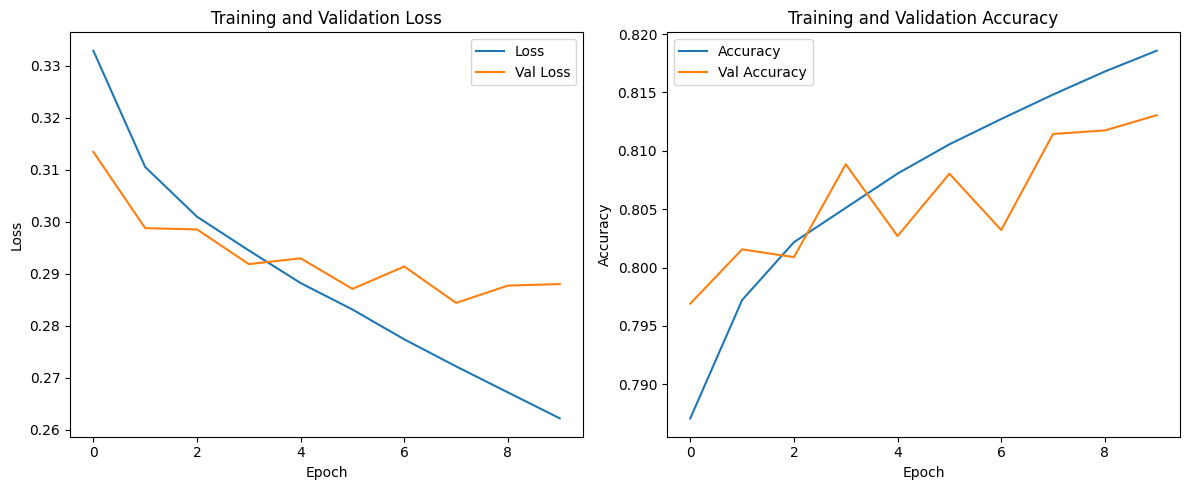


Generating visualizations for 2 sample image pairs...


2025-07-26 19:42:43,263 - INFO - Generated synthetic heatmap based on 10 detected thermal hotspots from 00075_regenerated_thermal.jpg using red+green spike detection.


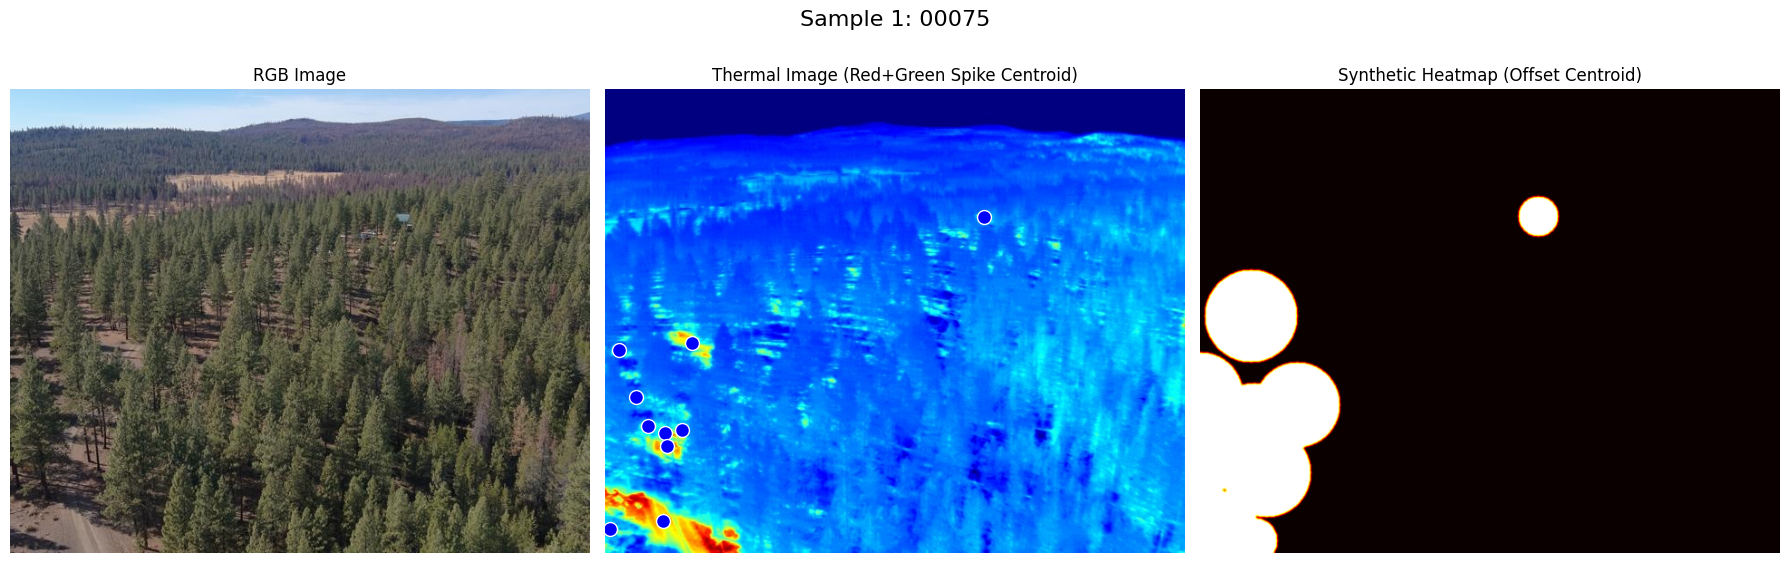

2025-07-26 19:42:45,070 - INFO - Generated synthetic heatmap based on 61 detected thermal hotspots from 00054_regenerated_thermal.jpg using red+green spike detection.


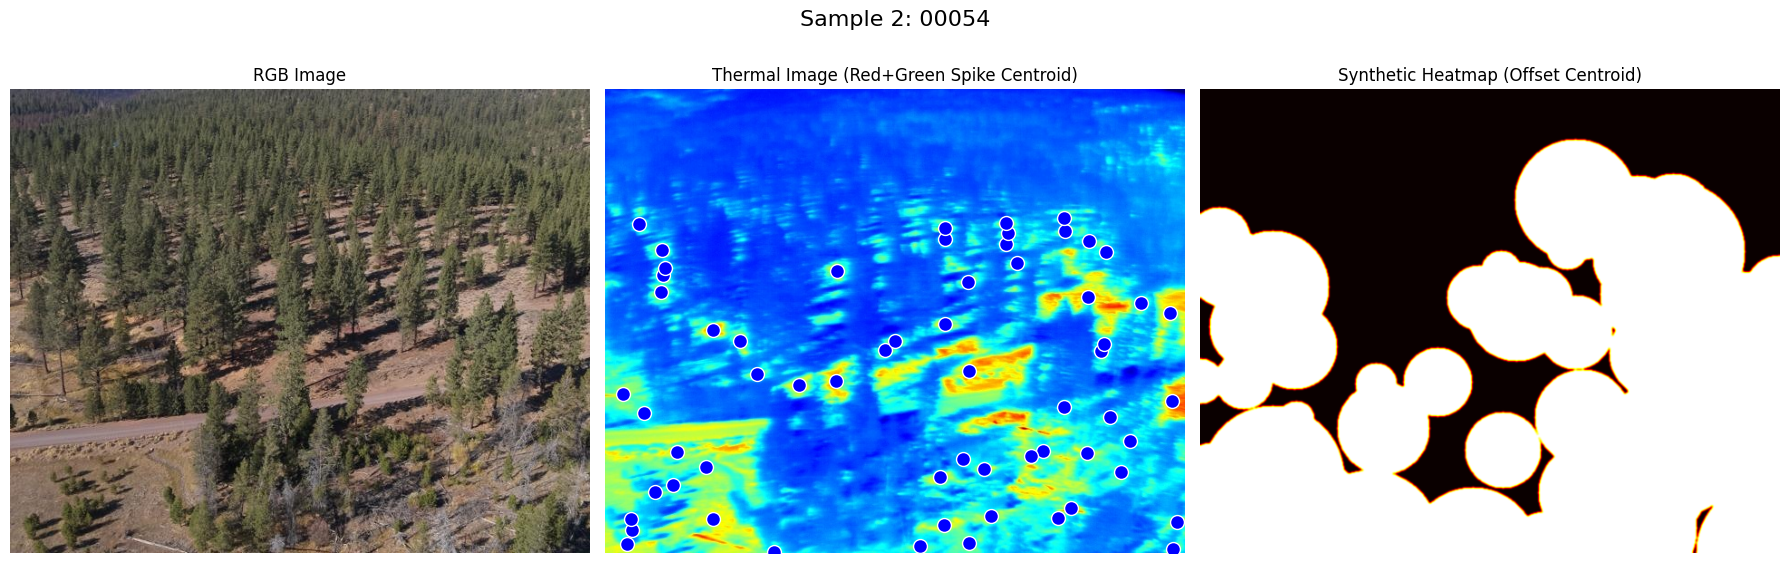


Visualization complete. Please review the generated plots.


In [57]:
# Cell 4 (Classification): Training and Visualization (Consistent with previous fixes)
# Ensure constants are defined if running this cell in isolation,
# and ensure paired_files, IMG_HEIGHT, IMG_WIDTH, RGB_CHANNELS, THERMAL_CHANNELS, GRID_SIZE, OUTPUT_BASE_DIR,
# model, train_dataset, val_dataset are defined from Cell 2 and Cell 3 execution before running this cell.

# This function is duplicated here for visualization specific centroid capture.
# It is very similar to generate_synthetic_heatmap but returns the drawn centers.
def generate_synthetic_heatmap_and_centers(img_height, img_width, thermal_image_path=None, num_fallback_hotspots=3, 
                                           min_radius=20, max_radius=80, affinity_offset=50, spike_intensity_threshold=180): # Red+Green Threshold
    """
    Generates a synthetic grayscale heatmap with "hotspots" and returns the drawn center points.
    Heat detection now uses the red AND green channels of the _regenerated_thermal.jpg image to identify spikes.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images result in a blank heatmap.
    Values are 0-1 (normalized). Ensures float32.
    
    Returns:
        tuple: (synthetic_heatmap, list_of_drawn_centers)
    """
    synthetic_heatmap = np.zeros((img_height, img_width), dtype=np.float32) # Ensure dtype is float32
    hotspot_locations = []
    synthetic_hotspot_drawn_centers = []

    is_fire_image = 'Fire' in os.path.dirname(thermal_image_path) if thermal_image_path else False

    if is_fire_image and thermal_image_path and os.path.exists(thermal_image_path):
        # Load as color image to analyze red and green channels
        thermal_img_raw_color = cv2.imread(thermal_image_path)
        if thermal_img_raw_color is not None:
            thermal_img_rgb = cv2.cvtColor(thermal_img_raw_color, cv2.COLOR_BGR2RGB)
            red_channel = thermal_img_rgb[:, :, 0] # Extract the red channel
            green_channel = thermal_img_rgb[:, :, 1] # Extract the green channel
            
            # Combine red and green channels to identify "spikes"
            spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)
            
            spike_intensity_map_resized = cv2.resize(spike_intensity_map, (img_width, img_height))
            
            # Apply Gaussian Blur before thresholding for better contour detection
            blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)
            
            # Threshold the combined intensity map to identify hot regions
            _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
            
            # Find contours of the hot regions
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                # Reduced minimum contour area to account for small spikes from drone images
                if cv2.contourArea(contour) > 10: 
                    M = cv2.moments(contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                        hotspot_locations.append((cx, cy))
            
            if hotspot_locations:
                logging.info(f"Generated synthetic heatmap based on {len(hotspot_locations)} detected thermal hotspots from {os.path.basename(thermal_image_path)} using red+green spike detection.")
            else:
                logging.warning(f"No significant thermal hotspots detected in {os.path.basename(thermal_image_path)} above spike intensity threshold {spike_intensity_threshold}. Falling back to random hotspots (for Fire image).")
                # Fallback to random hotspots if no thermal hotspots were found (only for Fire images)
                for _ in range(num_fallback_hotspots):
                    hotspot_locations.append((np.random.randint(0, img_width), np.random.randint(0, img_height)))
                logging.info(f"Generated {num_fallback_hotspots} random synthetic hotspots as a fallback for Fire image.")
        else:
            logging.warning(f"Could not load thermal image for intelligent synthetic heatmap: {thermal_image_path}. Generating blank heatmap (for No_Fire image or fallback for Fire).")
    else: # If not a fire image, or thermal path is invalid/missing for fire image
        logging.info(f"Image {os.path.basename(thermal_image_path)} is from No_Fire folder or path invalid. Synthetic heatmap creation with hotspots is not performed; generating blank heatmap.")

    # Place synthetic hotspots around identified thermal locations (only if hotspot_locations is populated)
    for center_x, center_y in hotspot_locations:
        # Add a random offset for "affinity"
        offset_x = np.random.randint(-affinity_offset, affinity_offset + 1)
        offset_y = np.random.randint(-affinity_offset, affinity_offset + 1)
        
        draw_x = np.clip(center_x + offset_x, 0, img_width - 1)
        draw_y = np.clip(center_y + offset_y, 0, img_height - 1)
        synthetic_hotspot_drawn_centers.append((draw_x, draw_y)) # Capture the drawn center

        radius = np.random.randint(min_radius, max_radius)
        cv2.circle(synthetic_heatmap, (draw_x, draw_y), radius, (1.0), -1) 
    
    synthetic_heatmap = cv2.GaussianBlur(synthetic_heatmap, (5, 5), 0)
    synthetic_heatmap = np.clip(synthetic_heatmap, 0.0, 1.0)
    
    return synthetic_heatmap, synthetic_hotspot_drawn_centers

def get_hotspot_centroids(image_path, spike_intensity_threshold=180): # Red+Green Threshold
    """
    Loads a thermal image, finds hot regions above a threshold in its combined red and green channels,
    and returns their centroids.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images return an empty list.
    Used for visualizing actual thermal centroids.
    """
    is_fire_image = 'Fire' in os.path.dirname(image_path) if image_path else False

    if is_fire_image and image_path and os.path.exists(image_path):
        # Load as color image to analyze red and green channels
        img_raw_color = cv2.imread(image_path)
        if img_raw_color is None:
            return []
        
        img_rgb = cv2.cvtColor(img_raw_color, cv2.COLOR_BGR2RGB)
        red_channel = img_rgb[:, :, 0] # Extract the red channel
        green_channel = img_rgb[:, :, 1] # Extract the green channel

        # Combine red and green channels to identify "spikes"
        spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)

        # Resize to common dimensions for consistency with other images
        spike_intensity_map_resized = cv2.resize(spike_intensity_map, (IMG_WIDTH, IMG_HEIGHT))

        # Apply Gaussian Blur before thresholding for better contour detection
        blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)

        _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        centroids = []
        for contour in contours:
            # Reduced minimum contour area to account for small spikes from drone images
            if cv2.contourArea(contour) > 10: 
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroids.append((cx, cy))
        return centroids
    else: # If not a fire image, return empty list
        logging.info(f"Image {os.path.basename(image_path)} is from No_Fire folder. Returning no centroids.")
        return []


# --- Model Training ---
print("Starting model training...")

# Check if model, train_dataset, val_dataset are available from Cell 3
if 'model' not in locals() or model is None or 'train_dataset' not in locals() or train_dataset is None:
    print("Error: Model or datasets are not available. Please run Cell 3 first to build the model and prepare datasets.")
else:
    # Calculate steps per epoch based on the length of data lists *before* converting to generator/dataset
    # This ensures consistency, as tf.data.Dataset.cardinality() might be UNKNOWN
    # Assuming train_rgb_patches and val_rgb_patches are available from Cell 2 after data loading
    if 'train_rgb_patches' in locals() and 'val_rgb_patches' in locals():
        train_steps_per_epoch = max(1, len(train_rgb_patches) // BATCH_SIZE)
        val_steps_per_epoch = max(1, len(val_rgb_patches) // BATCH_SIZE)
        
        print(f"Training with {train_steps_per_epoch} steps per epoch and {val_steps_per_epoch} validation steps.")

        history = model.fit(
            train_dataset,
            epochs=10, # You can adjust the number of epochs
            steps_per_epoch=train_steps_per_epoch,
            validation_data=val_dataset,
            validation_steps=val_steps_per_epoch
        )

        print("\nModel training complete.")

        # Plot training history
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Loss')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['binary_accuracy'], label='Accuracy')
        if 'val_binary_accuracy' in history.history:
            plt.plot(history.history['val_binary_accuracy'], label='Val Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()
    else:
        print("Error: 'train_rgb_patches' or 'val_rgb_patches' not found. Cannot calculate steps_per_epoch. Please ensure Cell 2 ran successfully.")


# --- Visualization for 2 Samples ---
print("\nGenerating visualizations for 2 sample image pairs...")

# Check if paired_files is available from Cell 2
if 'paired_files' not in locals() or not paired_files:
    print("Error: 'paired_files' list is not available. Please run Cell 2 first to load and pair data.")
else:
    samples_to_visualize = []
    fire_sample = None
    no_fire_sample = None

    # Separate fire and no-fire paths
    fire_paths = [fp for fp in paired_files if 'Fire' in os.path.dirname(fp['rgb'])]
    no_fire_paths = [fp for fp in paired_files if 'No_Fire' in os.path.dirname(fp['rgb'])]

    # Try to add one fire sample
    if fire_paths:
        fire_sample = random.choice(fire_paths)
        samples_to_visualize.append(fire_sample)
    
    # Try to add one no-fire sample, ensuring it's not a duplicate if fire_sample was also from no_fire_paths (unlikely but safe)
    if no_fire_paths and len(samples_to_visualize) < 2:
        # Create a temporary list to pick from, excluding the fire_sample if it was chosen
        temp_no_fire_paths = [p for p in no_fire_paths if p != fire_sample] 
        if temp_no_fire_paths: # Only if there are valid options left
            no_fire_sample = random.choice(temp_no_fire_paths)
            samples_to_visualize.append(no_fire_sample)
        
    # If still not 2 unique samples, fill from any remaining paired_files
    if len(samples_to_visualize) < 2 and len(paired_files) >= 2:
        temp_list = list(paired_files)
        random.shuffle(temp_list)
        for fp in temp_list:
            if fp not in samples_to_visualize:
                samples_to_visualize.append(fp)
                if len(samples_to_visualize) == 2:
                    break
    
    # Ensure we only visualize up to 2 samples
    samples_to_visualize = samples_to_visualize[:2]


    if not samples_to_visualize:
        print("No image pairs found to visualize after selection criteria. Please check your data or OUTPUT_BASE_DIR.")
    else:
        for i, file_pair in enumerate(samples_to_visualize):
            rgb_path = file_pair['rgb']
            thermal_path = file_pair['thermal']
            
            # Load images for display
            rgb_image = load_image_patch(rgb_path, IMG_HEIGHT, IMG_WIDTH, RGB_CHANNELS)
            # For displaying the thermal image directly, load it as color for visualization purposes
            thermal_image_display_color = cv2.imread(thermal_path)
            if thermal_image_display_color is not None:
                thermal_image_display_color = cv2.cvtColor(thermal_image_display_color, cv2.COLOR_BGR2RGB)
                thermal_image_display_color = cv2.resize(thermal_image_display_color, (IMG_WIDTH, IMG_HEIGHT))
            
            if rgb_image is None or thermal_image_display_color is None:
                print(f"Skipping visualization for {os.path.basename(rgb_path)} due to loading error.")
                continue

            # Get original thermal centroids (using red+green spike logic and Fire folder check)
            thermal_centroids = get_hotspot_centroids(thermal_path, spike_intensity_threshold=180) # Use 8-bit threshold

            # Generate synthetic heatmap and get the centers where hotspots were drawn (using red+green spike logic and Fire folder check)
            synthetic_heatmap, heatmap_drawn_centers = generate_synthetic_heatmap_and_centers(
                IMG_HEIGHT, IMG_WIDTH, thermal_image_path=thermal_path, spike_intensity_threshold=180 # Use 8-bit threshold
            )

            # Create plot
            fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns
            fig.suptitle(f"Sample {i+1}: {os.path.basename(rgb_path).replace('_aligned_rgb.jpg', '')}", fontsize=16)

            # Plot RGB Image
            axes[0].imshow(rgb_image)
            axes[0].set_title("RGB Image")
            axes[0].axis('off')

            # Plot Thermal Image (displayed as color if it was loaded as such) with its centroids
            axes[1].imshow(thermal_image_display_color) # Display the color thermal image
            axes[1].set_title("Thermal Image (Red+Green Spike Centroid)")
            axes[1].axis('off')
            for cx, cy in thermal_centroids:
                axes[1].plot(cx, cy, 'o', markerfacecolor='blue', markeredgecolor='white', markersize=10, label='Thermal Hotspot Centroid')

            # Plot Synthetic Heatmap with offset centroids
            axes[2].imshow(synthetic_heatmap, cmap='hot')
            axes[2].set_title("Synthetic Heatmap (Offset Centroid)")
            axes[2].axis('off')
            for dx, dy in heatmap_drawn_centers:
                axes[2].plot(dx, dy, 'x', markerfacecolor='lime', markeredgecolor='white', markersize=12, label='Heatmap Offset Centroid')
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()

print("\nVisualization complete. Please review the generated plots.")

Preparing for prediction and heatmap visualization...

Processing sample 1: RGB=00092_aligned_rgb.jpg, Thermal=00092_regenerated_thermal.jpg
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


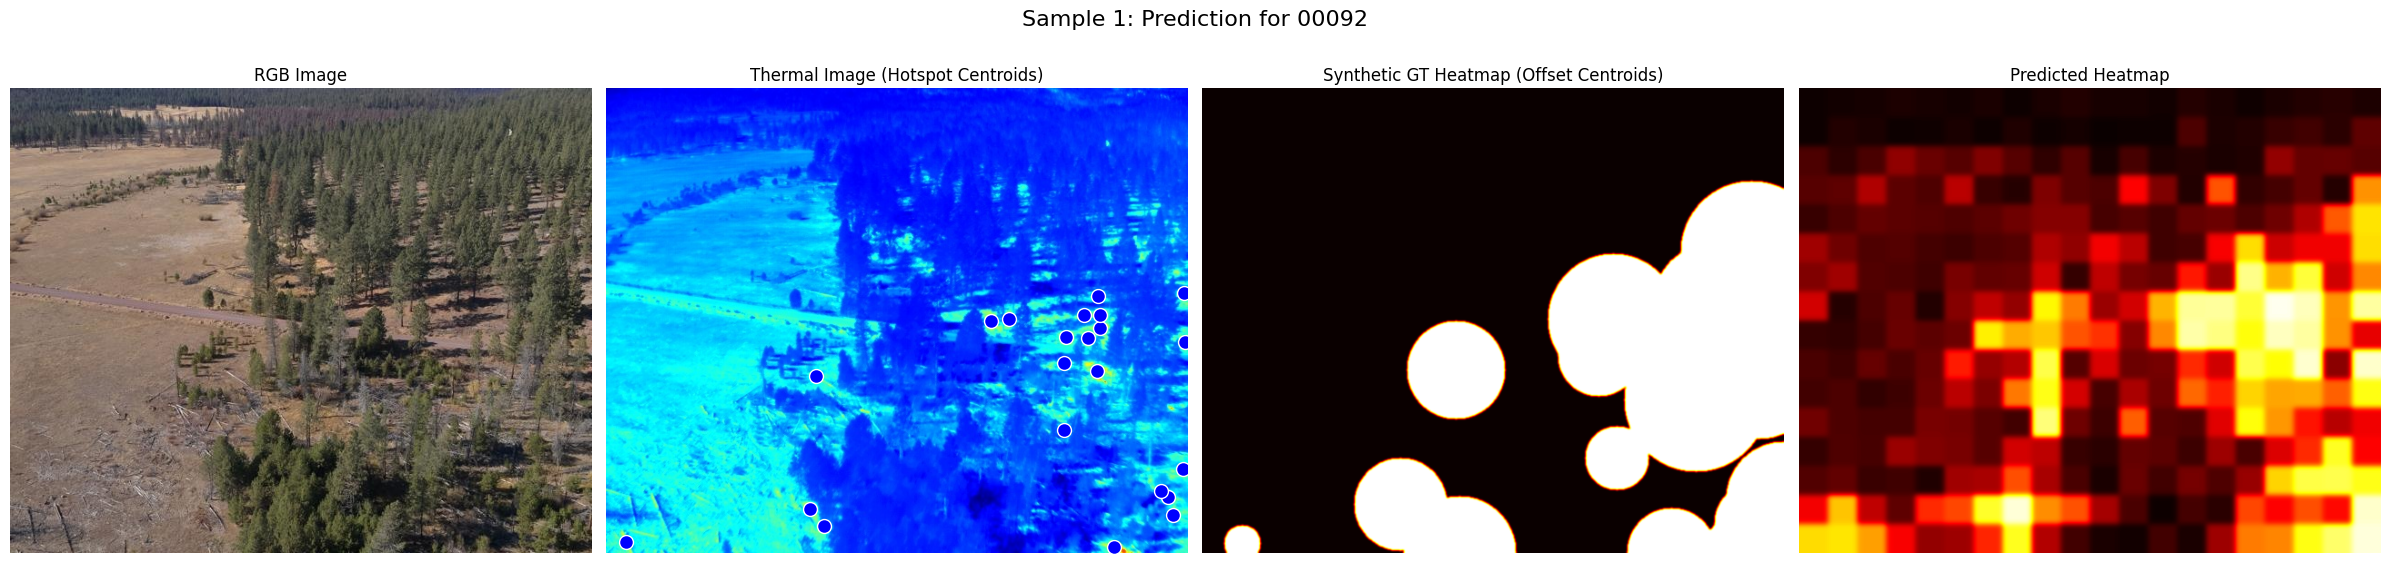

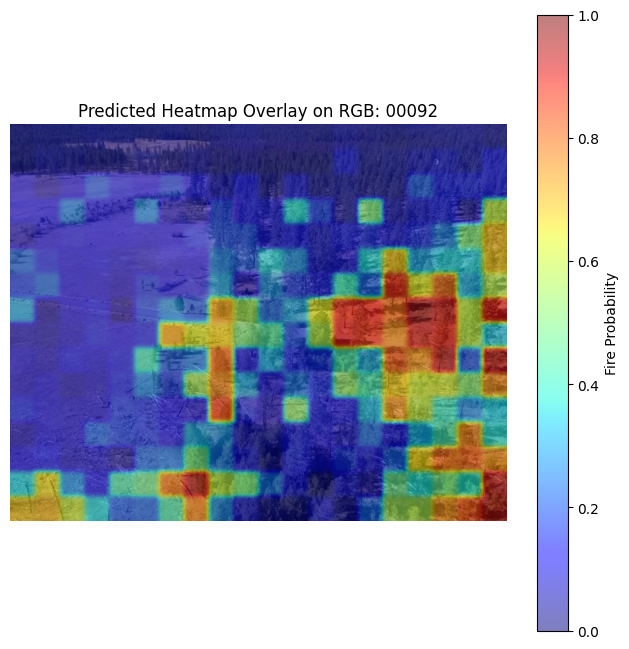


Processing sample 2: RGB=00573_aligned_rgb.jpg, Thermal=00573_regenerated_thermal.jpg
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


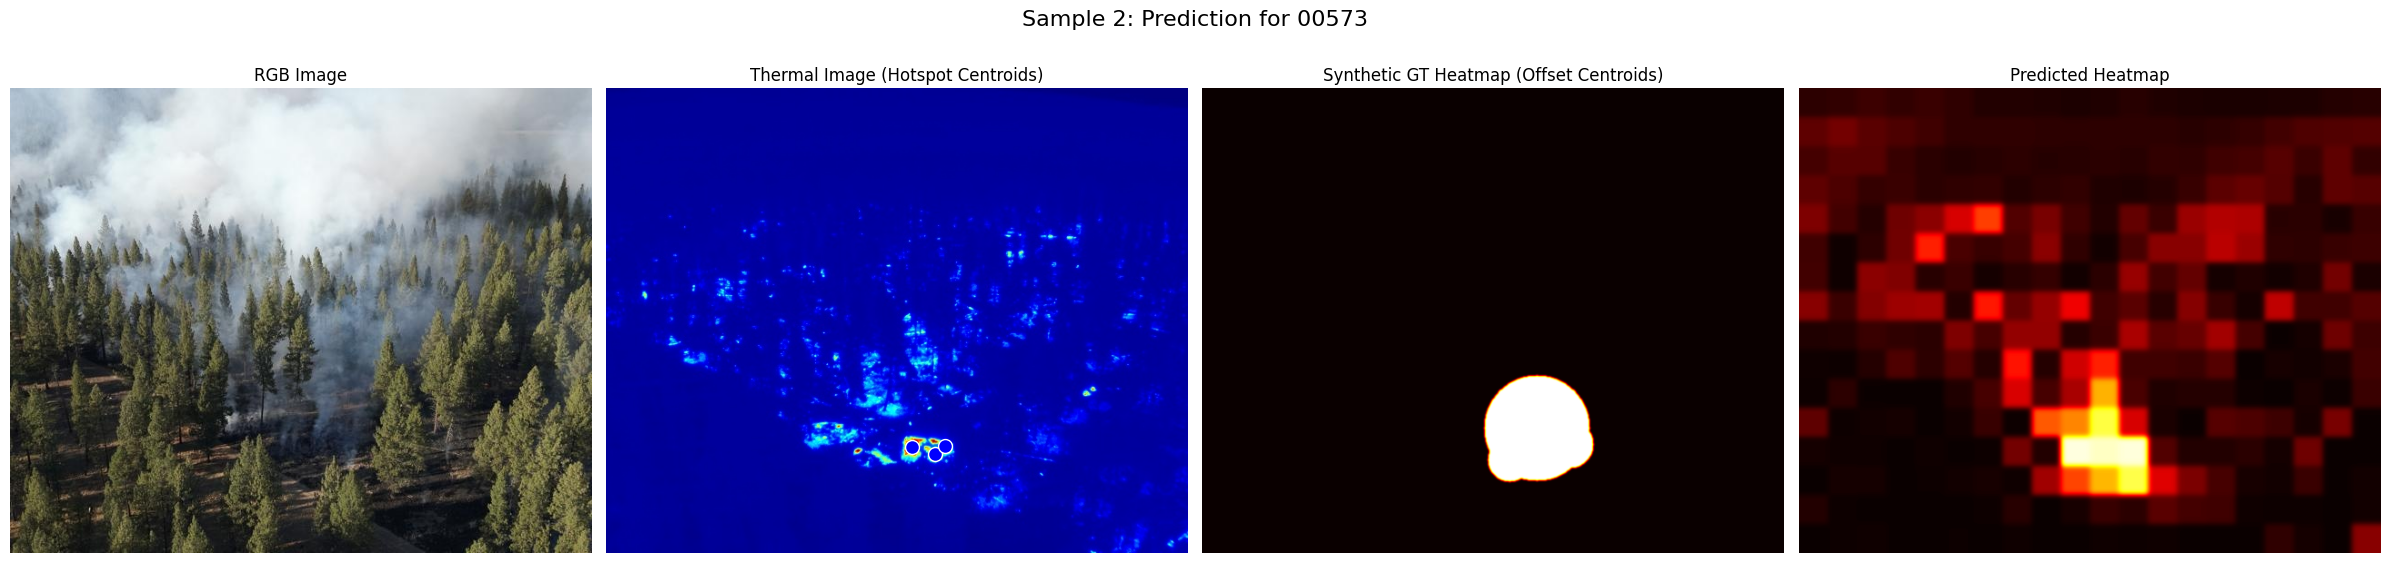

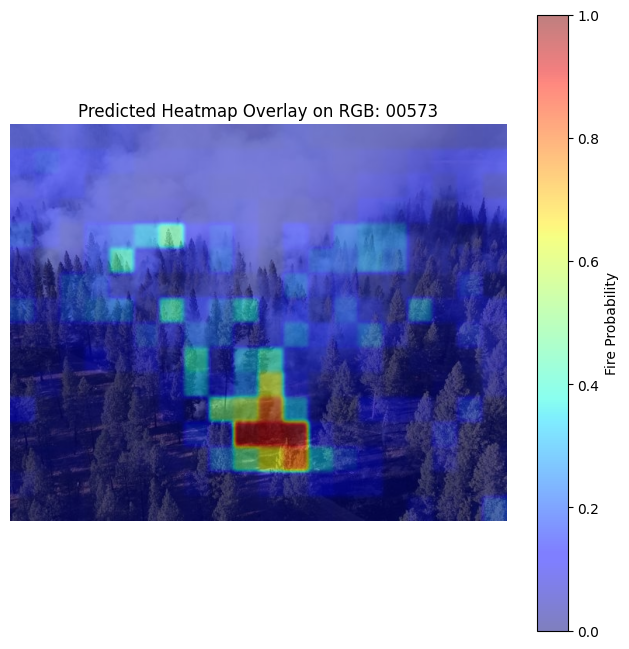


Prediction and visualization complete.
The plots show the original RGB and Thermal images, the synthetic ground truth heatmap, and the model's predicted heatmap for selected samples.


In [64]:
# Cell 5 (Classification): Prediction and Heatmap Visualization
def load_image_patch(image_path, img_height, img_width, target_channels):
    """
    Loads an image, resizes it, and normalizes pixel values.
    Handles RGB and grayscale thermal images. Ensures float32 and correct dimensions.
    """
    # logging.debug(f"Attempting to load image: {image_path} with {target_channels} channels.")
    image = None
    if target_channels == 3: # RGB
        image = cv2.imread(image_path)
        if image is None:
            # logging.error(f"Failed to load RGB image (imread returned None): {image_path}")
            return None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB
    elif target_channels == 1: # Thermal (grayscale)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            # logging.error(f"Failed to load Thermal image (imread returned None): {image_path}")
            return None
        image = np.expand_dims(image, axis=-1) if image.ndim == 2 else image # Ensure it's 3D if loaded as 2D
    else:
        # logging.error(f"Unsupported number of channels: {target_channels} for image: {image_path}")
        return None

    try:
        image = cv2.resize(image, (img_width, img_height))
        if target_channels == 1 and image.ndim == 2: # Safeguard again
            image = np.expand_dims(image, axis=-1)
        image = image.astype(np.float32) / 255.0 # Normalize to 0-1 range for 8-bit images
        # logging.debug(f"Successfully loaded and processed image: {image_path}")
        return image
    except Exception as e:
        # logging.error(f"Error during image resize/normalization/dimension check for {image_path}: {e}")
        return None

def generate_synthetic_heatmap_and_centers(img_height, img_width, thermal_image_path=None, num_fallback_hotspots=3, 
                                           min_radius=20, max_radius=80, affinity_offset=50, spike_intensity_threshold=180):
    """
    Generates a synthetic grayscale heatmap with "hotspots" and returns the drawn center points.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images result in a blank heatmap.
    """
    synthetic_heatmap = np.zeros((img_height, img_width), dtype=np.float32)
    hotspot_locations = []
    synthetic_hotspot_drawn_centers = []

    is_fire_image = 'Fire' in os.path.dirname(thermal_image_path) if thermal_image_path else False

    if is_fire_image and thermal_image_path and os.path.exists(thermal_image_path):
        thermal_img_raw_color = cv2.imread(thermal_image_path)
        if thermal_img_raw_color is not None:
            thermal_img_rgb = cv2.cvtColor(thermal_img_raw_color, cv2.COLOR_BGR2RGB)
            red_channel = thermal_img_rgb[:, :, 0]
            green_channel = thermal_img_rgb[:, :, 1]
            spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)
            spike_intensity_map_resized = cv2.resize(spike_intensity_map, (img_width, img_height))
            blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)
            _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                if cv2.contourArea(contour) > 10: 
                    M = cv2.moments(contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                        hotspot_locations.append((cx, cy))
            
            if not hotspot_locations:
                for _ in range(num_fallback_hotspots):
                    hotspot_locations.append((np.random.randint(0, img_width), np.random.randint(0, img_height)))
        # else: logging.warning(f"Could not load thermal image for intelligent synthetic heatmap: {thermal_image_path}. Generating blank heatmap.")
    # else: logging.info(f"Image {os.path.basename(thermal_image_path)} is from No_Fire folder or path invalid. Synthetic heatmap creation with hotspots is not performed; generating blank heatmap.")

    for center_x, center_y in hotspot_locations:
        offset_x = np.random.randint(-affinity_offset, affinity_offset + 1)
        offset_y = np.random.randint(-affinity_offset, affinity_offset + 1)
        draw_x = np.clip(center_x + offset_x, 0, img_width - 1)
        draw_y = np.clip(center_y + offset_y, 0, img_height - 1)
        synthetic_hotspot_drawn_centers.append((draw_x, draw_y))
        radius = np.random.randint(min_radius, max_radius)
        cv2.circle(synthetic_heatmap, (draw_x, draw_y), radius, (1.0), -1) 
    
    synthetic_heatmap = cv2.GaussianBlur(synthetic_heatmap, (5, 5), 0)
    synthetic_heatmap = np.clip(synthetic_heatmap, 0.0, 1.0)
    
    return synthetic_heatmap, synthetic_hotspot_drawn_centers

def get_hotspot_centroids(image_path, spike_intensity_threshold=180):
    """
    Loads a thermal image, finds hot regions above a threshold in its combined red and green channels,
    and returns their centroids.
    Only applies intelligent detection for 'Fire' folder images. 'No_Fire' images return an empty list.
    """
    is_fire_image = 'Fire' in os.path.dirname(image_path) if image_path else False

    if is_fire_image and image_path and os.path.exists(image_path):
        img_raw_color = cv2.imread(image_path)
        if img_raw_color is None:
            return []
        
        img_rgb = cv2.cvtColor(img_raw_color, cv2.COLOR_BGR2RGB)
        red_channel = img_rgb[:, :, 0]
        green_channel = img_rgb[:, :, 1]
        spike_intensity_map = ((red_channel.astype(np.float32) + green_channel.astype(np.float32)) / 2).astype(np.uint8)
        spike_intensity_map_resized = cv2.resize(spike_intensity_map, (IMG_WIDTH, IMG_HEIGHT))
        blurred_spike_intensity_map = cv2.GaussianBlur(spike_intensity_map_resized, (5, 5), 0)
        _, thresh = cv2.threshold(blurred_spike_intensity_map, spike_intensity_threshold, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        centroids = []
        for contour in contours:
            if cv2.contourArea(contour) > 10: 
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroids.append((cx, cy))
        return centroids
    else:
        return []

def load_multi_modal_grid_data(rgb_image_path, thermal_image_path, ground_truth_heatmap_path,
                               img_height, img_width, grid_size, num_heatmap_classes):
    """
    Loads full RGB and Thermal images, a ground truth heatmap (or generates a synthetic one),
    and extracts grid-sized patches with corresponding labels.
    
    Crucially, for 'No_Fire' images, heatmap generation is explicitly skipped,
    and a blank heatmap is used.
    """
    full_rgb = load_image_patch(rgb_image_path, img_height, img_width, RGB_CHANNELS)
    full_thermal = load_image_patch(thermal_image_path, img_height, img_width, THERMAL_CHANNELS)

    if full_rgb is None or full_thermal is None:
        return None, None, None

    ground_truth_heatmap = None
    is_fire_image = 'Fire' in os.path.dirname(thermal_image_path)

    if is_fire_image:
        if os.path.exists(ground_truth_heatmap_path):
            ground_truth_heatmap = cv2.imread(ground_truth_heatmap_path, cv2.IMREAD_GRAYSCALE)
            if ground_truth_heatmap is None:
                ground_truth_heatmap, _ = generate_synthetic_heatmap_and_centers(img_height, img_width, thermal_image_path)
            else:
                ground_truth_heatmap = cv2.resize(ground_truth_heatmap, (img_width, img_height), interpolation=cv2.INTER_LINEAR if num_heatmap_classes == 1 else cv2.INTER_NEAREST)
                ground_truth_heatmap = ground_truth_heatmap.astype(np.float32) / 255.0
        else:
            ground_truth_heatmap, _ = generate_synthetic_heatmap_and_centers(img_height, img_width, thermal_image_path)
    else:
        ground_truth_heatmap = np.zeros((img_height, img_width), dtype=np.float32)

    if ground_truth_heatmap is None:
        return None, None, None

    all_rgb_patches = []
    all_thermal_patches = []
    all_labels = []

    for y in range(0, img_height, grid_size):
        for x in range(0, img_width, grid_size):
            y_end = min(y + grid_size, img_height)
            x_end = min(x + grid_size, img_width)

            if (y_end - y) != grid_size or (x_end - x) != grid_size:
                continue

            rgb_patch = full_rgb[y:y_end, x:x_end]
            thermal_patch = full_thermal[y:y_end, x:x_end]
            
            patch_heatmap_region = ground_truth_heatmap[y:y_end, x:x_end]
            
            if num_heatmap_classes == 1:
                label = np.mean(patch_heatmap_region).astype(np.float32)
                label = np.clip(label, 0.0, 1.0)
            else:
                values, counts = np.unique(patch_heatmap_region.round(), return_counts=True)
                if len(values) == 0:
                    label = tf.keras.utils.to_categorical(0, num_classes=num_heatmap_classes).astype(np.float32)
                else:
                    label = values[np.argmax(counts)]
                    label = tf.keras.utils.to_categorical(int(label), num_classes=num_heatmap_classes).astype(np.float32)
            
            all_rgb_patches.append(rgb_patch)
            all_thermal_patches.append(thermal_patch)
            all_labels.append(label)

    return all_rgb_patches, all_thermal_patches, all_labels

print("Preparing for prediction and heatmap visualization...")

if 'model' not in locals() or model is None or 'paired_files' not in locals() or not paired_files:
    print("Error: Model or 'paired_files' list not available. Please ensure Cell 2 and Cell 3 ran successfully.")
else:
    samples_to_visualize = []
    fire_samples = [fp for fp in paired_files if 'Fire' in os.path.dirname(fp['rgb'])]
    no_fire_samples = [fp for fp in paired_files if 'No_Fire' in os.path.dirname(fp['rgb'])]

    if fire_samples:
        samples_to_visualize.append(random.choice(fire_samples))
    if no_fire_samples and len(samples_to_visualize) < 2:
        temp_no_fire_samples = [s for s in no_fire_samples if s not in samples_to_visualize]
        if temp_no_fire_samples:
            samples_to_visualize.append(random.choice(temp_no_fire_samples))
    
    while len(samples_to_visualize) < 2 and len(paired_files) > len(samples_to_visualize):
        chosen = random.choice(paired_files)
        if chosen not in samples_to_visualize:
            samples_to_visualize.append(chosen)

    if not samples_to_visualize:
        print("No sample images available for prediction visualization. Please check your data directory.")
    else:
        for i, file_pair in enumerate(samples_to_visualize):
            rgb_path = file_pair['rgb']
            thermal_path = file_pair['thermal']
            heatmap_path_dummy = file_pair['heatmap_dummy_path']

            print(f"\nProcessing sample {i+1}: RGB={os.path.basename(rgb_path)}, Thermal={os.path.basename(thermal_path)}")

            rgb_image_display = load_image_patch(rgb_path, IMG_HEIGHT, IMG_WIDTH, RGB_CHANNELS)
            thermal_image_display_color = cv2.imread(thermal_path)
            if thermal_image_display_color is not None:
                thermal_image_display_color = cv2.cvtColor(thermal_image_display_color, cv2.COLOR_BGR2RGB)
                thermal_image_display_color = cv2.resize(thermal_image_display_color, (IMG_WIDTH, IMG_HEIGHT))
            
            if rgb_image_display is None or thermal_image_display_color is None:
                print(f"Skipping visualization for {os.path.basename(rgb_path)} due to image loading error for display.")
                continue

            rgb_patches_for_prediction, thermal_patches_for_prediction, gt_labels_for_patches = load_multi_modal_grid_data(
                rgb_path, thermal_path, heatmap_path_dummy, IMG_HEIGHT, IMG_WIDTH, GRID_SIZE, NUM_HEATMAP_CLASSES
            )

            if rgb_patches_for_prediction is None or len(rgb_patches_for_prediction) == 0:
                print(f"Skipping prediction for {os.path.basename(rgb_path)} as no patches were extracted.")
                continue

            rgb_patches_array = np.array(rgb_patches_for_prediction, dtype=np.float32)
            thermal_patches_array = np.array(thermal_patches_for_prediction, dtype=np.float32)

            predicted_probabilities = model.predict([rgb_patches_array, thermal_patches_array])

            if NUM_HEATMAP_CLASSES == 1:
                predicted_probabilities = predicted_probabilities.flatten()
            
            predicted_heatmap = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.float32)
            patch_idx = 0
            for y in range(0, IMG_HEIGHT, GRID_SIZE):
                for x in range(0, IMG_WIDTH, GRID_SIZE):
                    y_end = min(y + GRID_SIZE, IMG_HEIGHT)
                    x_end = min(x + GRID_SIZE, IMG_WIDTH)

                    if (y_end - y) != GRID_SIZE or (x_end - x) != GRID_SIZE:
                        continue

                    if patch_idx < len(predicted_probabilities):
                        predicted_heatmap[y:y_end, x:x_end] = predicted_probabilities[patch_idx]
                        patch_idx += 1
            
            predicted_heatmap = cv2.GaussianBlur(predicted_heatmap, (GRID_SIZE // 2 + 1, GRID_SIZE // 2 + 1), 0)
            predicted_heatmap = np.clip(predicted_heatmap, 0.0, 1.0)

            thermal_centroids = get_hotspot_centroids(thermal_path)

            synthetic_heatmap_gt, heatmap_drawn_centers_gt = generate_synthetic_heatmap_and_centers(
                IMG_HEIGHT, IMG_WIDTH, thermal_image_path=thermal_path
            )

            fig, axes = plt.subplots(1, 4, figsize=(24, 6))
            fig.suptitle(f"Sample {i+1}: Prediction for {os.path.basename(rgb_path).replace('_aligned_rgb.jpg', '')}", fontsize=16)

            axes[0].imshow(rgb_image_display)
            axes[0].set_title("RGB Image")
            axes[0].axis('off')

            axes[1].imshow(thermal_image_display_color)
            axes[1].set_title("Thermal Image (Hotspot Centroids)")
            axes[1].axis('off')
            for cx, cy in thermal_centroids:
                axes[1].plot(cx, cy, 'o', markerfacecolor='blue', markeredgecolor='white', markersize=10, label='Thermal Hotspot Centroid')

            axes[2].imshow(synthetic_heatmap_gt, cmap='hot')
            axes[2].set_title("Synthetic GT Heatmap (Offset Centroids)")
            axes[2].axis('off')
            for dx, dy in heatmap_drawn_centers_gt:
                axes[2].plot(dx, dy, 'x', markerfacecolor='lime', markeredgecolor='white', markersize=12, label='Heatmap Offset Centroid')

            axes[3].imshow(predicted_heatmap, cmap='hot', vmin=0, vmax=1)
            axes[3].set_title("Predicted Heatmap")
            axes[3].axis('off')
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            plt.figure(figsize=(8, 8))
            plt.imshow(rgb_image_display)
            plt.imshow(predicted_heatmap, cmap='jet', alpha=0.5, vmin=0, vmax=1)
            plt.title(f"Predicted Heatmap Overlay on RGB: {os.path.basename(rgb_path).replace('_aligned_rgb.jpg', '')}")
            plt.axis('off')
            plt.colorbar(label='Fire Probability')
            plt.show()

print("\nPrediction and visualization complete.")
print("The plots show the original RGB and Thermal images, the synthetic ground truth heatmap, and the model's predicted heatmap for selected samples.")